In [1]:
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model\\research'

In [4]:
import os
# os.chdir("..")

import pandas as pd
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import numpy as np
%matplotlib inline

# 2. Load the data:

In [5]:
clipped_train = pd.read_parquet("Artifacts/feature_engineering/data_clipped/train.parquet")
clipped_test = pd.read_parquet("Artifacts/feature_engineering/data_clipped/test.parquet")

unclipped_train = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/train.parquet")
unclipped_test = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/test.parquet")

In [6]:
def create_dep_indep_features(df:pd.DataFrame):
    """
    Splits the data into dependent(y) and independent(X) features:
    """
    df.dropna(inplace=True)
    X = df.drop(columns=['customerid', 'churn'])
    y = df['churn']
    return X, y   

In [7]:
def separate_col_by_dtypes(df:pd.DataFrame) -> list():
    """
    Returns the numerical and categorical feature names as list:
    """
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()
    return (numerical_features, categorical_features)

In [33]:
def spot_check_algorithms(X_train, y_train, preprocessor):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    results = []
    names = []
    
    models = {
        'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'DT': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'RF': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
        'EXTCLF': ExtraTreesClassifier(class_weight='balanced', n_estimators=100, random_state=42),
        'GB': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'XG': XGBClassifier(scale_pos_weight=2, eval_metric='logloss', random_state=42, verbosity=0),
        'KNN': KNeighborsClassifier(),
        'LDA': LinearDiscriminantAnalysis(),
        'SVC': SVC()
    }
    
    for name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('clf', model)
        ])
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        results.append(scores)
        names.append(name)
        print(f"{name:25s} | F1: {np.mean(scores)*100:.2f}% ± {np.std(scores)*100:.2f}%")

    fig = plt.figure(figsize=(12, 7))
    fig.suptitle('Algorithm Comparison')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.axhline(y=scores.mean(), color="green", linestyle="--", label=f"Overall mean = {avg_f1_score:.3f}")
    ax.set_xticklabels(names)
    plt.show()

# 1. Spot-checking Clipped-Data:

### Splitting the data into train and test set:

In [9]:
X_train, y_train = create_dep_indep_features(df=clipped_train)
X_test, y_test = create_dep_indep_features(df=clipped_test)
numerical_features, categorical_features = separate_col_by_dtypes(df=X_train)

### Defining the pre-processor:

In [10]:
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

### Listing the algorithms for comparison:

LR                        | F1: 80.10% ± 0.95%
DT                        | F1: 76.50% ± 1.68%
RF                        | F1: 84.16% ± 0.79%
EXTCLF                    | F1: 83.88% ± 0.71%
GB                        | F1: 84.06% ± 0.69%
XG                        | F1: 83.27% ± 0.88%
KNN                       | F1: 82.38% ± 0.80%
LDA                       | F1: 82.99% ± 0.86%
SVC                       | F1: 84.36% ± 0.45%


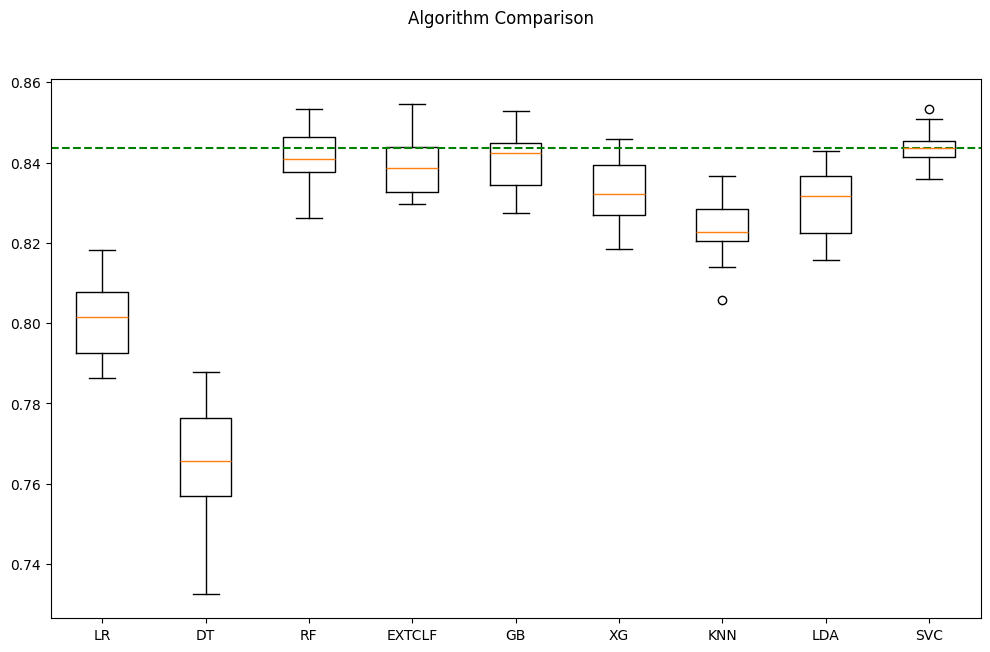

In [34]:
spot_check_algorithms(X_train, y_train, preprocessor)

I will move forward with these **5 algorithms** for experiment tracking on `MlFlow`:
1. SVC                       | F1: 84.36% ± 0.45%
2. GB                        | F1: 84.06% ± 0.69%
3. RF                        | F1: 84.16% ± 0.79%
4. EXTCLF                    | F1: 83.88% ± 0.71%
5. XG                        | F1: 83.27% ± 0.88%

# 2. Spot-checking Unclipped-Data:

## Splitting the data into train and test set:

In [35]:
X_train, y_train = create_dep_indep_features(df=unclipped_train)
X_test, y_test = create_dep_indep_features(df=unclipped_test)
numerical_features, categorical_features = separate_col_by_dtypes(df=X_train)

## Defining the pre-processor:

In [36]:
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

## Listing the algorithms for comparison:

LR                        | F1: 80.18% ± 0.84%
DT                        | F1: 76.64% ± 1.31%
RF                        | F1: 84.22% ± 0.84%
EXTCLF                    | F1: 83.80% ± 0.65%
GB                        | F1: 84.10% ± 0.66%
XG                        | F1: 83.21% ± 0.91%
KNN                       | F1: 82.22% ± 0.80%
LDA                       | F1: 82.99% ± 0.81%
SVC                       | F1: 84.37% ± 0.50%


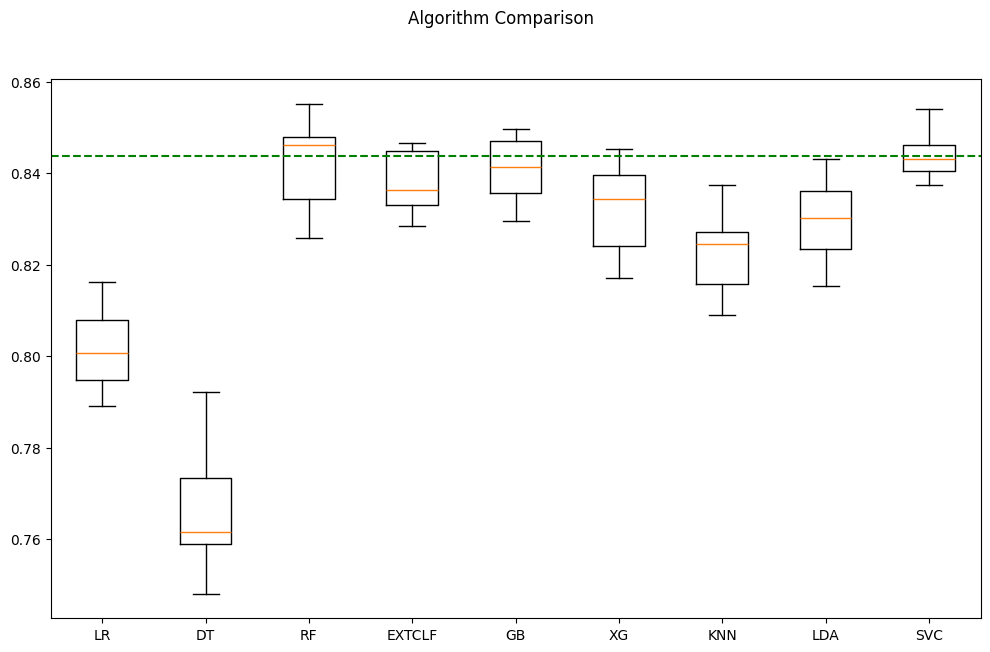

In [37]:
spot_check_algorithms(X_train, y_train, preprocessor)

I will move forward with these **5 algorithms** for experiment tracking on `MlFlow`:
1. RF                        | F1: 84.22% ± 0.84%
2. GB                        | F1: 84.10% ± 0.66%
3. SVC                       | F1: 84.37% ± 0.50%
4. EXTCLF                    | F1: 83.80% ± 0.65%
5. XG                        | F1: 83.21% ± 0.91%